This notebook contains simulations of delta method under different conditions.

In [26]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import math

In [27]:
random.seed(42)

#Generate sample g(mu) = (1 / mu)
def generate_sample(n, m, a, b, g):
    sample = np.random.uniform(a, b, size=(n, m))
    sample = sample.mean(axis=1)
    sample_g = g(sample)
    return sample, sample_g

$$
Let\: \sqrt{n}(\widehat{\theta}_n - \theta_0)\xrightarrow{d}N(0,\sigma^2)\\
$$

and variance is a small number around 0

then by the mean value theorem

$$ exists \:\overline{\theta_0}\:lying\:between\:\widehat{\theta}_0 \: and\: \theta_0\:such\:that\\ $$
$$ \frac{dg(\overline{\theta})}{d\theta} = \frac{g(\widehat{\theta}_n) - g(\theta_0)}
{\widehat{\theta}_n - \theta_0}   \\ $$
$$
g(\widehat{\theta}_n)=g(\theta_0)+\frac{dg(\overline{\theta})}{d\theta}
(\widehat{\theta}_n-\theta_0)
$$
by substracting and multiplying both sides we get
$$ \sqrt{n}(g(\widehat{\theta}_n) - g(\theta_0)) = \frac{dg(\overline{\theta})}{d\theta}
\sqrt{n}\cdot(\widehat{\theta}_n - \theta_0) $$

$$\frac{dg(\overline{\theta})}{d\theta}\xrightarrow{P}\frac{dg(\theta_0)}{d\theta}$$
because g is continious and both borders converge to a point by probability (applying continious mapping theorem)

$$ \frac{dg(\overline{\theta})}{d\theta}\sqrt{n}(\widehat{\theta}_n - \theta_0) $$
By applying Slutsky's theorem we get

$$ (\frac{dg(\theta_0)}{d\theta})^2\cdot\sigma^2 $$

https://www.statlect.com/asymptotic-theory/delta-method

$$ Asymptotical \: distribution \: of\: \sqrt{n}(g(\widehat{\theta}_n) - g(\theta_0)) : $$
$$ N(0, (\frac{dg(\theta_0)}{d\theta})^2\cdot\sigma^2) $$

$$ g(\overline{x}_n) \approx N(g(\mu), (\frac{dg(\theta_0)}{d\theta})^2\cdot\sigma^2) $$

We can apply Delta method for approximation near mean value if 
$$ g'(\mu) \neq 0 \: and \: g \: is \: differentiable \: at \: \mu $$

Sample variance 0.0006450780728458924
Normal curve 40.00551476509721 1.0324095324952398


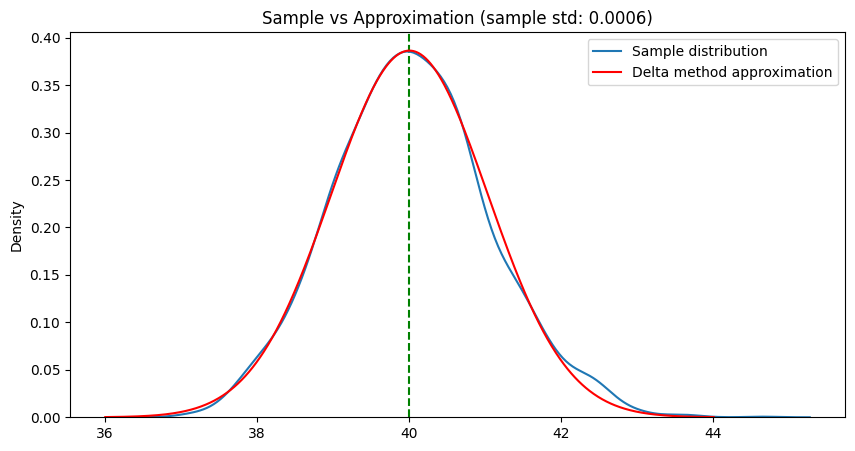

In [28]:
def plot(title : str, g, center):
    #Calculate mean and std
    sigma = sample.std()
    mu = sample.mean()

    print("Sample variance", sigma)
    se = sigma

    #Center and spread of normal curve
    mu_g = center(mu)
    sigma_g = np.sqrt(se ** 2 * g(mu) ** 2)

    #Visual
    plt.figure(figsize=(10, 5))
    x_values = np.linspace(mu_g - 4, mu_g + 4, 1000)
    y_values = sc.stats.norm.pdf(x_values, loc=mu_g, scale=sigma_g)
    plt.axvline(x=mu_g, color='green', linestyle='--')

    print("Normal curve", mu_g, sigma_g)

    sns.kdeplot(sample_g, label="Sample distribution")
    plt.plot(x_values, y_values, color='red', label="Delta method approximation")
    plt.title(f"{title}")
    plt.legend()

sample, sample_g = generate_sample(3000, 500, 0, 0.05, g = lambda x : 1 / x)
std = sample.std()
plot(f"Sample vs Approximation (sample std: {std.round(4)})", g = lambda x : -1 / (x ** 2), center=lambda x : 1 / x)

Let's generate a sample with higher variance

Sample variance 0.0639272913795343
Normal curve 2.0056103678747492 0.2571458001956182


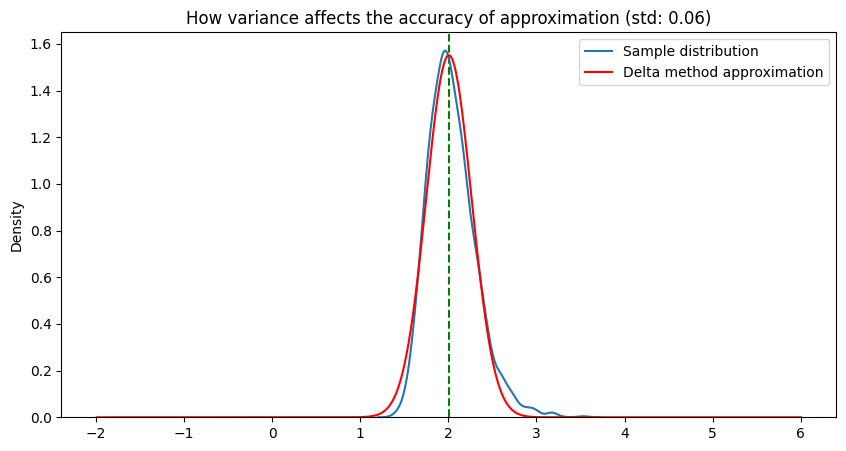

In [29]:
sample, sample_g = generate_sample(3000, m=20, a=0, b=1, g = lambda x : 1 / x)
std = sample.std()
plot(f"How variance affects the accuracy of approximation (std: {std.round(2)})", g = lambda x : -1 / (x ** 2), center=lambda x : 1 / x)

Sample's variance affects the accuracy of approximation. For better approximation variance should be around 0

Let's try different functions. For example log

Sample variance 6.447852566193663e-05
Normal curve -0.0005005505686281524 6.451080850354432e-05


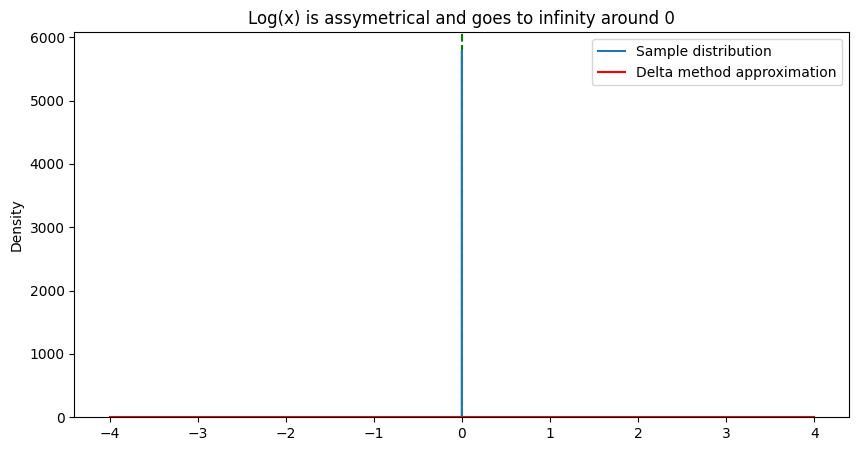

In [30]:
sample, sample_g = generate_sample(2000, 20, 0.999, 1, g = lambda x : np.log(x))
std = sample.std()
plot(f"Log(x) is assymetrical and goes to infinity around 0", g = lambda x : 1 / x, center=lambda x : np.log(x))

Log is an assymetrical function that is defined only for positive numbers, thus approximation can produce strange CI's. Also we can't approximate the log function near 0. 

Sometimes linear approximation isn't enough. For g(x) = x^3, approximation struggles to catch the skewness of new distribution.

Sample variance 0.1286987818002851
Normal curve 8.002402271604723 1.544694535561464


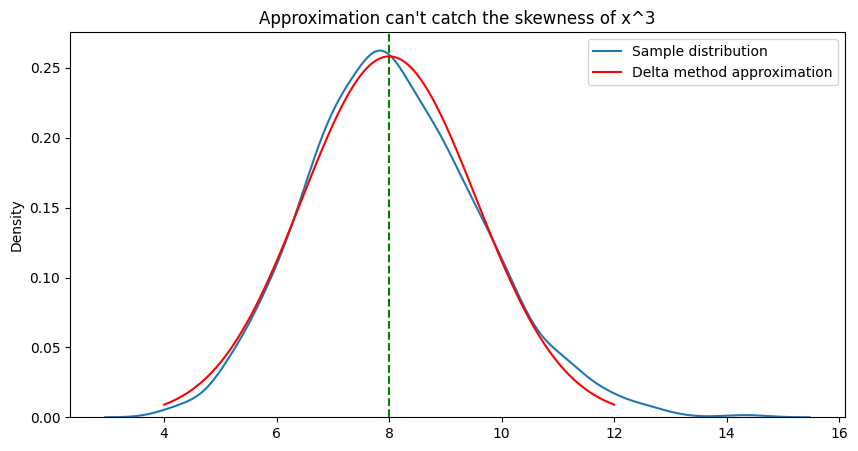

In [31]:
sample, sample_g = generate_sample(2000, 20, 1, 3, g = lambda x : x ** 3)
std = sample.std()
plot(f"Approximation can't catch the skewness of x^3", g = lambda x : 3 * (x ** 2), center=lambda x : x ** 3)